# Chapter 11 Figures – Phase-Space Topology & Attractor Catalog

Illustrative diagnostics of the 10 canonical attractor basins and Row-13 dynamics  
**Stable Corridor (#10)** as preferred resilience zone  

Key updates (December 2025 revisions):
- Fig 11.1: Pure canonical basin catalog (#1–10) with illustrative colors (no thermodynamic meaning). Small markers show approximate baseline positions of manuscript examples: ants (Mutualism Ellipsoid #1), Venice plateau (Stable Corridor #10), late VOC (Exploitationism Sinkhole #2). No ensemble clouds or proxy gradient — focus on attractor topology.
- Fig 11.2: Row-13 interaction profiles for all 10 basins (#1–10), full move names (Mutualism, Commensalism, Exploitationism, Competition, Amensalism, Neutralism), numbered titles for consistency with Ch. 11.2 catalog.
- Fig 11.3: Four primary overlapping wells with updated names (Exploitationism Sinkhole, Rigid Trap, etc.), kill-switch ε ≈ 1.1 line, and Bifurcation Ridge overlay as dynamic separatrix/tipping boundary. Ellipse elongation reflects asymmetric costs (greater flexibility along X/economic metabolism vs. higher friction along Y/governance density).
- Fig 11.5: Complexity surface (illustrative merger resilience)

Repo: https://github.com/MementoMori15x6/15x6-sim  
Open to PRs/refinements — attractor boundaries, ridge position, surface functions, or new examples welcome.  

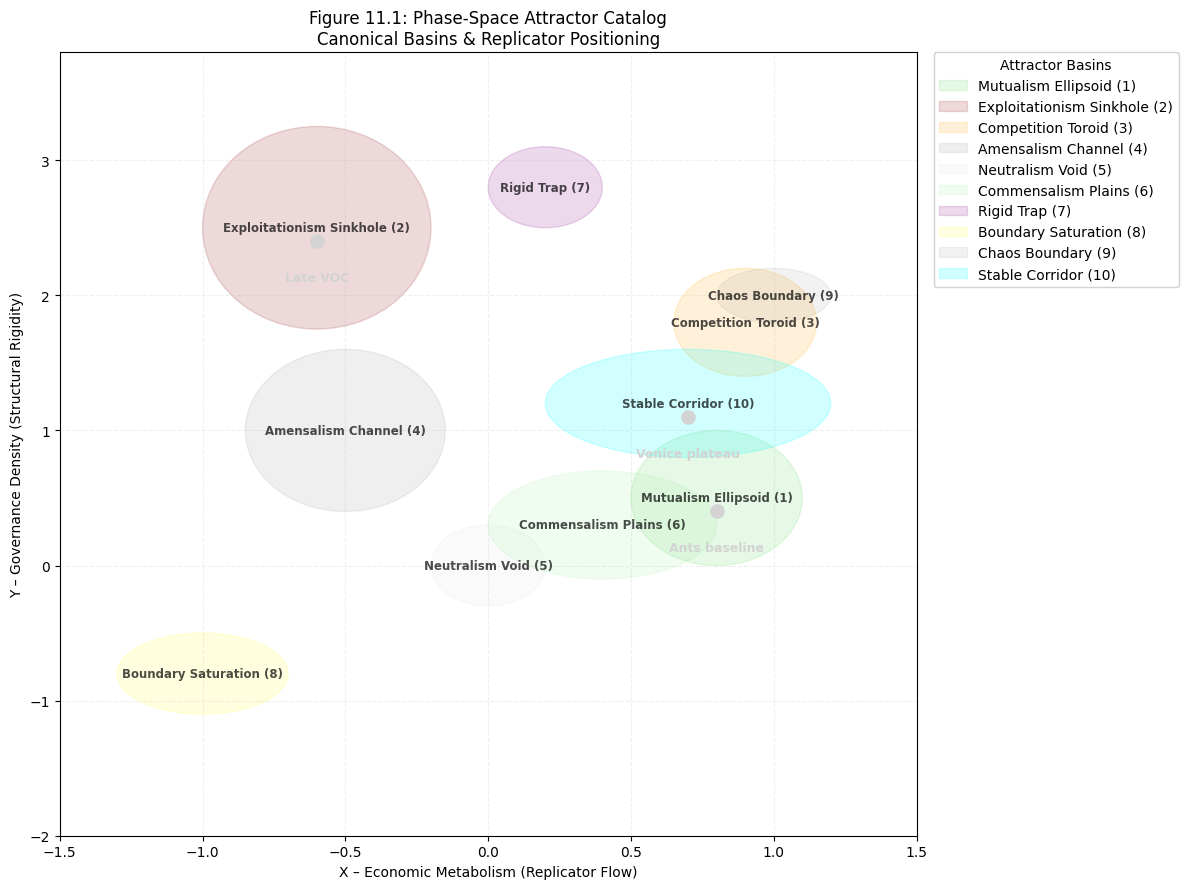

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np
import os

# Reset and Config
plt.switch_backend('agg')
plt.close('all')
FIG_SIZE = (12, 9)

# 1. Canonical Attractors
ATTRACTORS = [
    {"name": "Mutualism Ellipsoid (1)", "xy": (0.8, 0.5), "width": 0.6, "height": 1.0, "color": "limegreen", "alpha": 0.12},
    {"name": "Exploitationism Sinkhole (2)", "xy": (-0.6, 2.5), "width": 0.8, "height": 1.5, "color": "darkred", "alpha": 0.15},
    {"name": "Competition Toroid (3)", "xy": (0.9, 1.8), "width": 0.5, "height": 0.8, "color": "orange", "alpha": 0.15},
    {"name": "Amensalism Channel (4)", "xy": (-0.5, 1.0), "width": 0.7, "height": 1.2, "color": "gray", "alpha": 0.12},
    {"name": "Neutralism Void (5)", "xy": (0.0, 0.0), "width": 0.4, "height": 0.6, "color": "lightgray", "alpha": 0.10},
    {"name": "Commensalism Plains (6)", "xy": (0.4, 0.3), "width": 0.8, "height": 0.8, "color": "lightgreen", "alpha": 0.12},
    {"name": "Rigid Trap (7)", "xy": (0.2, 2.8), "width": 0.4, "height": 0.6, "color": "purple", "alpha": 0.15},
    {"name": "Boundary Saturation (8)", "xy": (-1.0, -0.8), "width": 0.6, "height": 0.6, "color": "yellow", "alpha": 0.12},
    {"name": "Chaos Boundary (9)", "xy": (1.0, 2.0), "width": 0.4, "height": 0.4, "color": "gray", "alpha": 0.10},
    {"name": "Stable Corridor (10)", "xy": (0.7, 1.2), "width": 1.0, "height": 0.8, "color": "cyan", "alpha": 0.18},
]

# 2. Replicator Case Studies
examples = [
    {"name": "Ants baseline", "xy": (0.8, 0.4)},
    {"name": "Venice plateau", "xy": (0.7, 1.1)},
    {"name": "Late VOC", "xy": (-0.6, 2.4)},
]

fig, ax = plt.subplots(figsize=FIG_SIZE)

# 3. Draw Attractor Basins
basin_handles = []
for zone in ATTRACTORS:
    patch = Ellipse(zone['xy'], zone['width'], zone['height'],
                    color=zone['color'], alpha=zone['alpha'], fill=True)
    ax.add_patch(patch)

    # Basin Name (Centered inside the ellipse)
    ax.text(zone['xy'][0], zone['xy'][1], zone['name'],
            fontsize=8.5, ha='center', va='center',
            color='black', fontweight='bold', alpha=0.7)
    basin_handles.append(patch)

# 4. Draw Replicator Markers & SINGLE Centered Labels
for ex in examples:
    # Marker
    ax.scatter(ex['xy'][0], ex['xy'][1], color='lightgray', marker='o', s=90, zorder=15)

    # Clean Label: Centered horizontally, placed directly underneath
    ax.text(ex['xy'][0], ex['xy'][1] - 0.22, ex['name'],
            fontsize=9, ha='center', va='top',
            color='lightgray', fontweight='semibold', zorder=20)

# 5. Layout & Centering Constraints
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-2.0, 3.8) # Adjusted to clear space for the Rigid Trap at the top
ax.set_xlabel('X – Economic Metabolism (Replicator Flow)')
ax.set_ylabel('Y – Governance Density (Structural Rigidity)')
ax.set_title('Figure 11.1: Phase-Space Attractor Catalog\nCanonical Basins & Replicator Positioning')
ax.grid(True, alpha=0.2, linestyle='--')

# 6. External Legend Positioning
ax.legend(basin_handles, [z['name'] for z in ATTRACTORS],
          loc='upper left', bbox_to_anchor=(1.02, 1.0),
          borderaxespad=0., title='Attractor Basins', framealpha=0.9)

plt.tight_layout()

# 7. Export
os.makedirs('figures', exist_ok=True)
save_path = 'figures/fig_11_1_final_clean.png'
fig.savefig(save_path, dpi=300, bbox_inches='tight')

# Display result
from IPython.display import display
display(fig)

Figure saved to: figures/fig_11_2_row13_profiles_updated.png


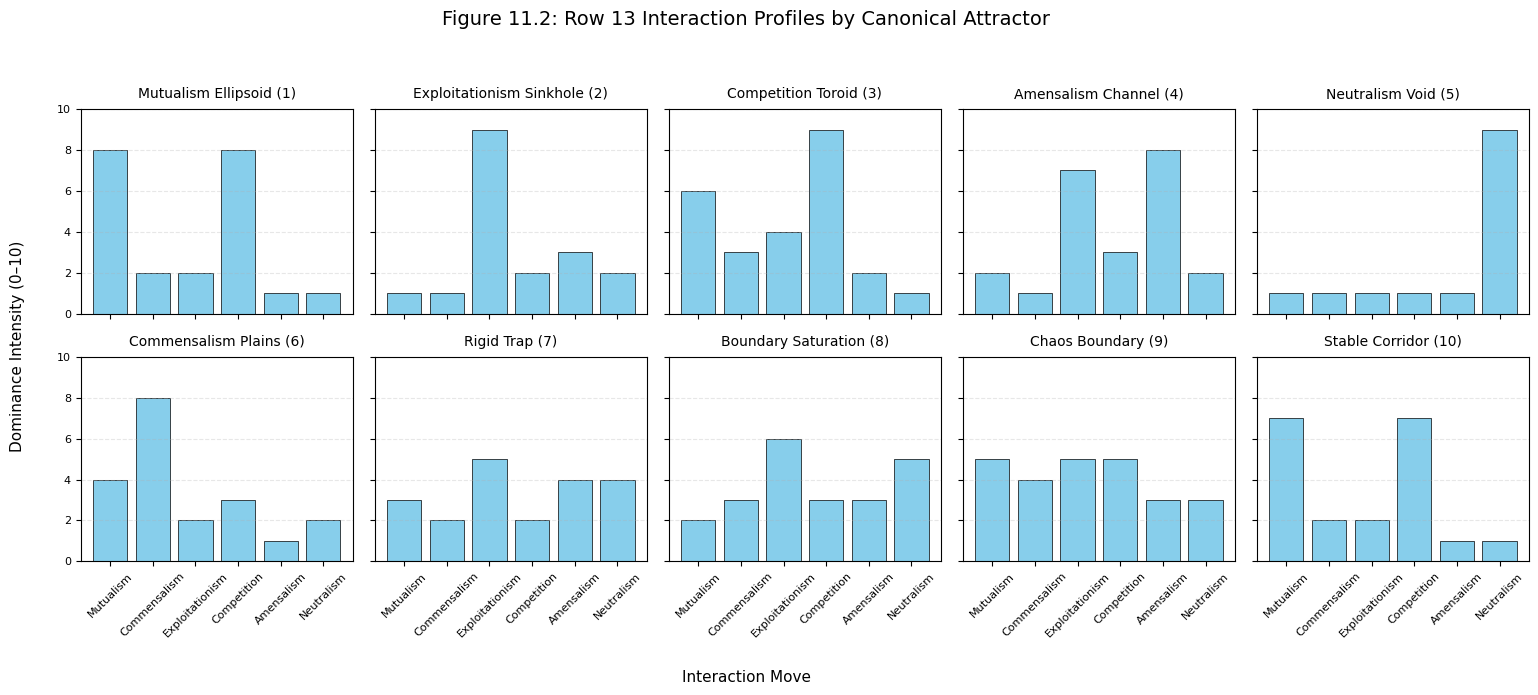

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import display

plt.switch_backend('agg')
plt.close('all')

# Locked 10 canonical attractors – illustrative Row 13 dominance (0–10 scale)
profiles = {
    "Mutualism Ellipsoid (1)": [8.0, 2.0, 2.0, 8.0, 1.0, 1.0],
    "Exploitationism Sinkhole (2)": [1.0, 1.0, 9.0, 2.0, 3.0, 2.0],
    "Competition Toroid (3)": [6.0, 3.0, 4.0, 9.0, 2.0, 1.0],
    "Amensalism Channel (4)": [2.0, 1.0, 7.0, 3.0, 8.0, 2.0],
    "Neutralism Void (5)": [1.0, 1.0, 1.0, 1.0, 1.0, 9.0],
    "Commensalism Plains (6)": [4.0, 8.0, 2.0, 3.0, 1.0, 2.0],
    "Rigid Trap (7)": [3.0, 2.0, 5.0, 2.0, 4.0, 4.0],
    "Boundary Saturation (8)": [2.0, 3.0, 6.0, 3.0, 3.0, 5.0],
    "Chaos Boundary (9)": [5.0, 4.0, 5.0, 5.0, 3.0, 3.0],
    "Stable Corridor (10)": [7.0, 2.0, 2.0, 7.0, 1.0, 1.0],
}

moves = ['Mutualism', 'Commensalism', 'Exploitationism', 'Competition', 'Amensalism', 'Neutralism']

# 2 rows × 5 columns layout
fig, axes = plt.subplots(2, 5, figsize=(16, 7), sharey=True, sharex=True)
axes = axes.flatten()

for i, (name, values) in enumerate(profiles.items()):
    ax = axes[i]
    ax.bar(moves, values, color='skyblue', edgecolor='black', linewidth=0.5)
    ax.set_title(name, fontsize=10, pad=8)
    ax.set_ylim(0, 10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

# Remove any empty subplots (not needed here)
for j in range(len(profiles), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Figure 11.2: Row 13 Interaction Profiles by Canonical Attractor', fontsize=14, y=0.98)
fig.text(0.5, 0.02, 'Interaction Move', ha='center', fontsize=11)
fig.text(0.04, 0.5, 'Dominance Intensity (0–10)', va='center', rotation='vertical', fontsize=11)

fig.tight_layout(rect=[0.06, 0.06, 1, 0.94])

# Save
os.makedirs('figures', exist_ok=True)
save_path = 'figures/fig_11_2_row13_profiles_updated.png'
fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved to: {save_path}")

# Display inline for troubleshooting (Jupyter/Colab)
display(fig)

plt.close(fig)

Figure saved to: figures/fig_11_3_four_wells_kill_switch_ridge.png


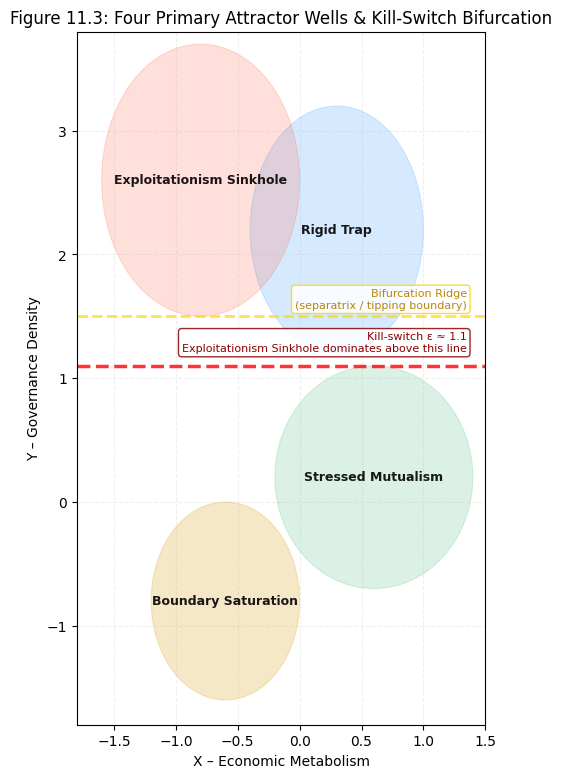

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import os
from IPython.display import display

plt.switch_backend('agg')
plt.close('all')

fig, ax = plt.subplots(figsize=(9, 9))  # Square for balanced wells

ax.set_xlim(-1.8, 1.5)
ax.set_ylim(-1.8, 3.8)
ax.set_xlabel('X – Economic Metabolism')
ax.set_ylabel('Y – Governance Density')
ax.set_title('Figure 11.3: Four Primary Attractor Wells & Kill-Switch Bifurcation')
ax.grid(True, alpha=0.2, linestyle='--')

# 4 primary overlapping wells (updated names, aligned to locked catalog)
wells = [
    {"name": "Stressed Mutualism", "xy": (0.6, 0.2), "width": 1.6, "height": 1.8, "color": "mediumseagreen", "alpha": 0.18},
    {"name": "Rigid Trap", "xy": (0.3, 2.2), "width": 1.4, "height": 2.0, "color": "dodgerblue", "alpha": 0.18},  # was Hierarchical Cooling
    {"name": "Boundary Saturation", "xy": (-0.6, -0.8), "width": 1.2, "height": 1.6, "color": "goldenrod", "alpha": 0.25},
    {"name": "Exploitationism Sinkhole", "xy": (-0.8, 2.6), "width": 1.6, "height": 2.2, "color": "tomato", "alpha": 0.20},  # was Parasitism Terminal Descent
]

for well in wells:
    patch = Ellipse(well['xy'], well['width'], well['height'],
                    color=well['color'], alpha=well['alpha'], fill=True,
                    linestyle='-', linewidth=0.8)
    ax.add_patch(patch)
    ax.text(well['xy'][0], well['xy'][1], well['name'], fontsize=9,
            ha='center', va='center', color='black', fontweight='bold', alpha=0.9)

# Kill-switch line & label
ax.axhline(y=1.1, color='red', linestyle='--', linewidth=2.5, alpha=0.8)
ax.text(1.35, 1.2, 'Kill-switch ε ≈ 1.1\nExploitationism Sinkhole dominates above this line',
        fontsize=8, color='darkred', ha='right', va='bottom',
        bbox=dict(facecolor='white', edgecolor='darkred', boxstyle='round,pad=0.3', alpha=0.85))

# Bifurcation Ridge overlay (dashed yellow line, dynamic separatrix)
ax.axhline(y=1.5, color='gold', linestyle='--', linewidth=2, alpha=0.7)
ax.text(1.35, 1.55, 'Bifurcation Ridge\n(separatrix / tipping boundary)',
        fontsize=8, color='darkgoldenrod', ha='right', va='bottom',
        bbox=dict(facecolor='white', edgecolor='gold', boxstyle='round,pad=0.3', alpha=0.85))

ax.set_aspect('equal')

# Save
os.makedirs('figures', exist_ok=True)
save_path = 'figures/fig_11_3_four_wells_kill_switch_ridge.png'
fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved to: {save_path}")

# Display inline for troubleshooting
display(fig)

plt.close(fig)

Figure saved to: figures/fig_11_5_complexity_surface.png


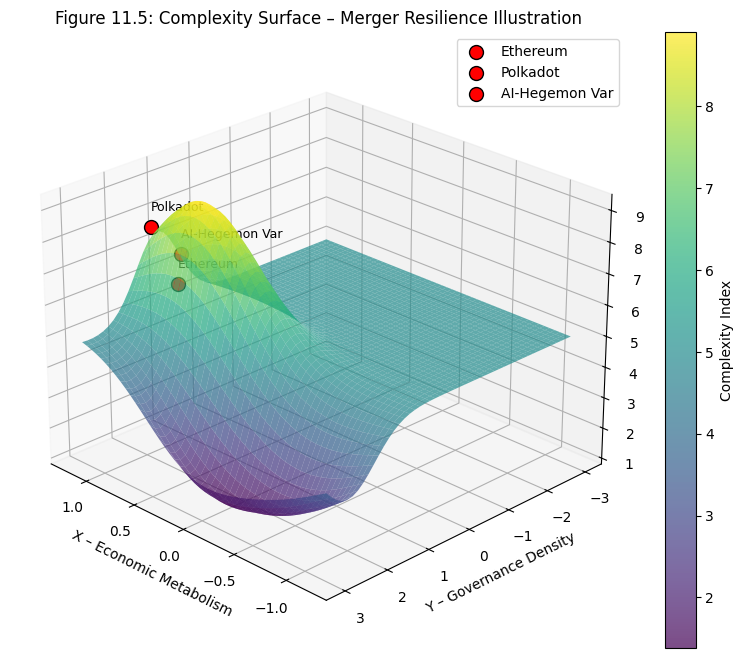

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

plt.switch_backend('agg')
plt.close('all')

# Dummy complexity values (illustrative)
replicators = {
    "Ethereum": {"x": 0.80, "y": 1.63, "z": 6.5, "proxy": 24.0},
    "Polkadot": {"x": 0.84, "y": 2.14, "z": 8.5, "proxy": 25.0},
    "AI-Hegemon Var": {"x": 0.76, "y": 1.63, "z": 7.5, "proxy": 19.0},
}

# Grid for surface
x = np.linspace(-1.2, 1.2, 50)
y = np.linspace(-3.0, 3.0, 50)
X, Y = np.meshgrid(x, y)

Z = 5 + 4 * np.exp(-((X - 0.7)**2 + (Y - 1.2)**2) / 0.5)
Z -= 3 * np.exp(-((X + 0.6)**2 + (Y - 2.5)**2) / 0.8)
Z -= 2 * np.exp(-((X - 0.2)**2 + (Y - 2.8)**2) / 0.4)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7, edgecolor='none')

for name, data in replicators.items():
    ax.scatter(data['x'], data['y'], data['z'], color='red', s=100, label=name,
               edgecolor='black', zorder=10)
    ax.text(data['x'], data['y'], data['z'] + 0.5, name, fontsize=9)

ax.set_xlabel('X – Economic Metabolism')
ax.set_ylabel('Y – Governance Density')
ax.set_title('Figure 11.5: Complexity Surface – Merger Resilience Illustration')
fig.colorbar(surf, ax=ax, label='Complexity Index')

ax.legend()
ax.view_init(elev=25, azim=135)

save_path = 'figures/fig_11_5_complexity_surface.png'
os.makedirs('figures', exist_ok=True)
fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved to: {save_path}")
# Display inline for troubleshooting (Jupyter/Colab)
display(fig)
plt.show()